# 11 — DNN regressor for Sérsic parameters

Train a CNN+MLP to map a galaxy image directly to its 7-D Sérsic parameter vector. At inference time this replaces a few thousand Adam iterations with a single forward pass — a useful technique for very large surveys.

In [1]:
# Bootstrap: make `lensing` importable when running notebooks/ directly.
import sys
from pathlib import Path
repo = Path.cwd().resolve().parent
if str(repo) not in sys.path:
    sys.path.insert(0, str(repo))

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

import lensing as gl
# Device-agnostic: prefer MPS (Apple GPU) → CUDA → CPU.
# Pass device="cpu" if you need to force the CPU path (e.g. for
# operators that have no MPS kernel yet, or for reproducibility).
device, dtype = gl.config.setup(seed=42)
print(f"using device: {device}")


/Users/simone/miniconda3/envs/dev/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


using device: mps


In [2]:
from torch.utils.data import DataLoader

train = gl.ml.datasets.SersicParamDataset(n_samples=1500, npix=48,
                                           deltapix=0.05, seed=0)
val   = gl.ml.datasets.SersicParamDataset(n_samples=200, npix=48,
                                           deltapix=0.05, seed=10000)
train_loader = DataLoader(train, batch_size=32, shuffle=True)
val_loader   = DataLoader(val,   batch_size=32)

model = gl.ml.models.SersicRegressor(in_channels=1, n_outputs=7)
history = gl.ml.train.fit_model(
    model, train_loader, val_loader,
    loss_fn=nn.MSELoss(),
    lr=1e-3, epochs=10,
    metrics={'mse': gl.ml.train.mse},
    log_every=1,
)


epoch   1/10  train_loss=1.9144  val_loss=1.6817  mse=1.9144
epoch   2/10  train_loss=1.4137  val_loss=1.4983  mse=1.4137
epoch   3/10  train_loss=1.1274  val_loss=1.1719  mse=1.1274
epoch   4/10  train_loss=0.6846  val_loss=0.6088  mse=0.6846
epoch   5/10  train_loss=0.4997  val_loss=0.5377  mse=0.4997
epoch   6/10  train_loss=0.4655  val_loss=0.5044  mse=0.4655
epoch   7/10  train_loss=0.4353  val_loss=0.4910  mse=0.4353
epoch   8/10  train_loss=0.3760  val_loss=0.3629  mse=0.3760
epoch   9/10  train_loss=0.3569  val_loss=0.3779  mse=0.3569
epoch  10/10  train_loss=0.3571  val_loss=0.3960  mse=0.3571


## Per-parameter accuracy and validation

Three indicators per output dimension:

* **Pearson correlation r**: linear correlation between
  predicted and true; r = 1 perfect, r = 0 random.
* **Robust scatter σ_residual = 1.4826 × MAD**: the
  outlier-resistant 1σ width of (pred − truth).
* **Bias = ⟨pred − truth⟩**: systematic offset, should be
  ≪ σ_residual.

These three numbers fully describe the regressor's
predictive quality on each parameter.

In [3]:
from lensing.ml.datasets import PARAM_KEYS

test = gl.ml.datasets.SersicParamDataset(n_samples=300, npix=48,
                                          deltapix=0.05, seed=98765)
preds, truths = [], []
model.eval()
with torch.no_grad():
    for x, y in DataLoader(test, batch_size=64):
        # Move to the trained model's device, then back to CPU
        # for downstream NumPy / Matplotlib code.
        preds.append(model(x.to(device)).cpu().numpy())
        truths.append(y.numpy())
preds = np.vstack(preds); truths = np.vstack(truths)


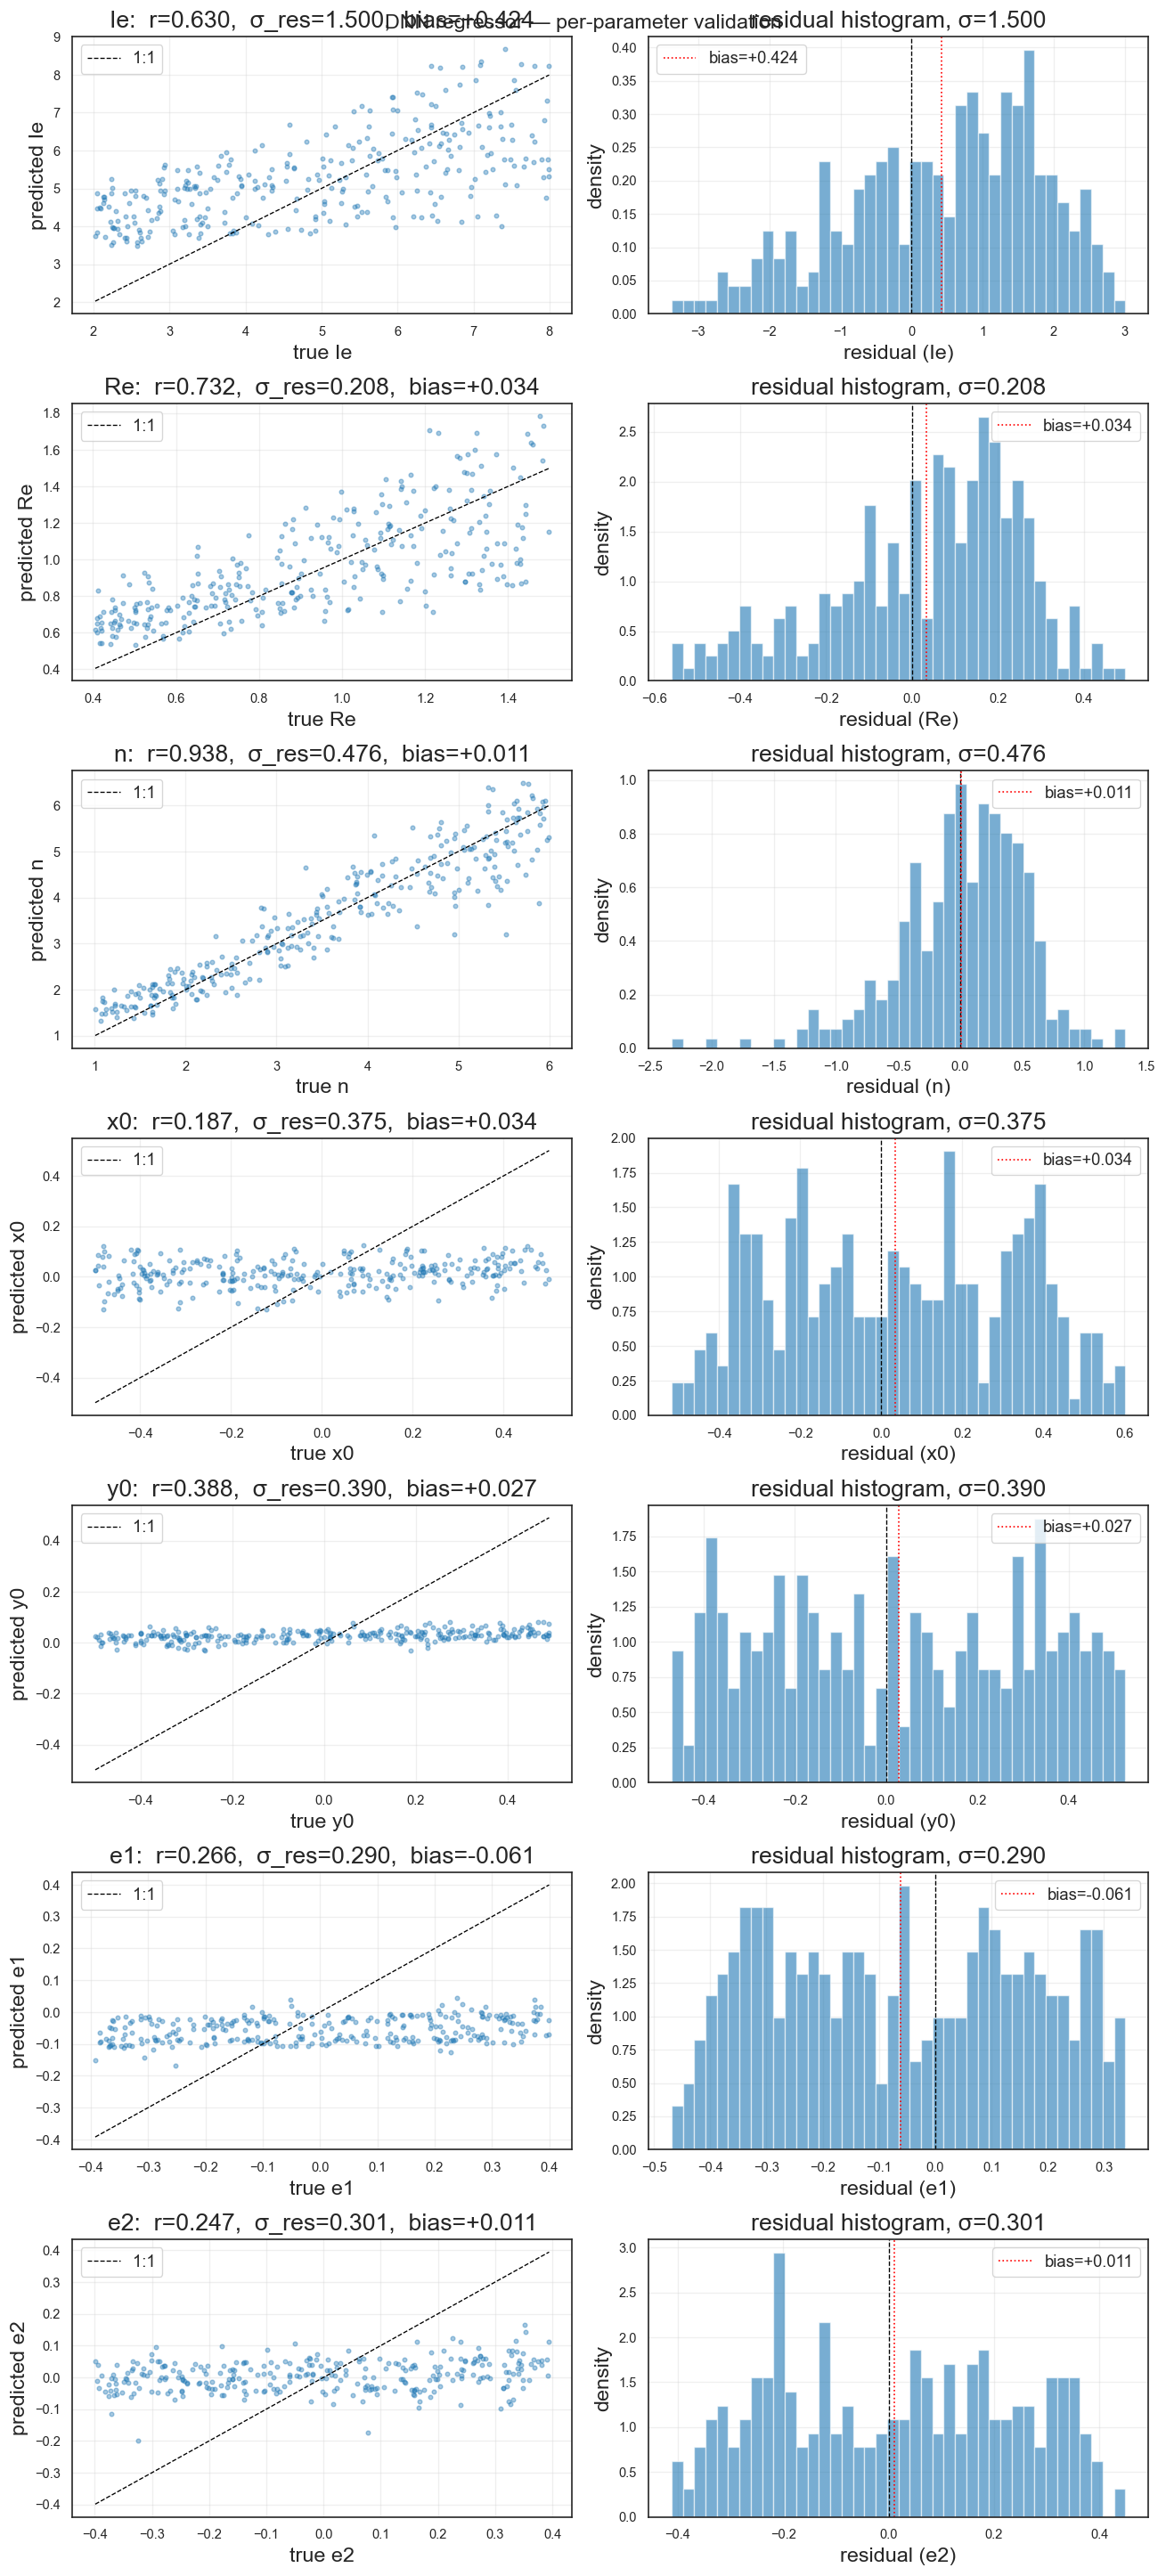

=== Pearson r ===
  Ie: r :      +0.6298
  Re: r :      +0.7315
  n: r  :      +0.9382
  x0: r :      +0.1871
  y0: r :      +0.3877
  e1: r :       +0.266
  e2: r :      +0.2466

=== Bias ===
  Ie: bias :      +0.4239
  Re: bias :     +0.03389
  n: bias  :     +0.01076
  x0: bias :     +0.03386
  y0: bias :     +0.02722
  e1: bias :     -0.06138
  e2: bias :       +0.011

=== Robust scatter ===
  Ie: sigma :         +1.5
  Re: sigma :      +0.2082
  n: sigma  :      +0.4764
  x0: sigma :      +0.3749
  y0: sigma :      +0.3904
  e1: sigma :      +0.2903
  e2: sigma :      +0.3009


In [4]:
fig, _, summary = gl.viz.diagnostics.plot_regression_diagnostics(
    truths, preds, param_names=PARAM_KEYS,
    title='DNN regressor — per-parameter validation',
)
plt.show()

print(gl.viz.diagnostics.format_summary(
    {f'{k}: r':       summary[k]['r']     for k in PARAM_KEYS}, 'Pearson r'))
print()
print(gl.viz.diagnostics.format_summary(
    {f'{k}: bias':    summary[k]['bias']  for k in PARAM_KEYS}, 'Bias'))
print()
print(gl.viz.diagnostics.format_summary(
    {f'{k}: sigma':   summary[k]['sigma'] for k in PARAM_KEYS}, 'Robust scatter'))


## Comparison vs. classical Adam fit

How much does inference speed up if we use the DNN as a one-shot estimator vs. running Adam from scratch on each image?

In [5]:
import time

x_one, y_true = test[0]
t0 = time.perf_counter()
with torch.no_grad():
    y_dnn = model(x_one.unsqueeze(0).to(device))[0].cpu().numpy()
t_dnn = time.perf_counter() - t0
print(f'DNN inference: {t_dnn*1e3:.2f} ms')

# Adam fit baseline
xy = train._xy
t0 = time.perf_counter()
galaxy = gl.light.Sersic(Ie=1., Re=1., n=2.5, x0=0., y0=0., e1=0., e2=0.)
res = gl.inference.fit(
    galaxy, xy, x_one[0],
    gl.inference.ReducedChiSquared(sigma=0.05, n_params=7),
    lr=0.05, epochs=500,
)
t_adam = time.perf_counter() - t0
print(f'Adam fit (500 epochs): {t_adam*1e3:.0f} ms — speedup ~ {t_adam/t_dnn:.0f}x')


DNN inference: 93.83 ms
Adam fit (500 epochs): 382 ms — speedup ~ 4x
